In [194]:
%matplotlib inline
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import madrigalWeb.madrigalWeb
import re
import os
import h5py
import numpy as np

In [195]:
#CHANGE ME
user_fullname = "Anthony Abubakar"
user_email = "aabubakar@g.ucla.edu"
user_affiliation = "UCLA"

maddat = madrigalWeb.madrigalWeb.MadrigalData('https://data.amisr.com/madrigal/')
# maddat = madrigalWeb.madrigalWeb.MadrigalData('https://cedar.openmadrigal.org/')

In [196]:
#instrument codes for AMISR
instcodes={'PFISR':61,
          'RISR-N':91,
          'RISR-C':92}

In [197]:
# Find an experiment that happened in the following time interval:
st=datetime.datetime(2026,7,21,0,0,0)
et=datetime.datetime(2026,7,22,0,0,0)
expList = maddat.getExperiments(instcodes['PFISR'],
                    st.year, st.month, st.day, st.hour, st.minute, st.second,
                    et.year, et.month, et.day, et.hour, et.minute, et.second)
for exp in expList:
    print(exp)

print("Finished running...")

id: 30003610
realUrl: http://data.amisr.com/madrigal/madExperiment.cgi?exp=experiments0/2026/pfa/21jul26c&displayLevel=0&expTitle=MSWinds26H.v01+-+D-region+E-region+F-region+local+measurements
url: http://data.amisr.com/madrigal/madtoc/experiments0/2026/pfa/21jul26c
name: MSWinds26H.v01 - D-region E-region F-region local measurements
siteid: 3
sitename: SRI
instcode: 61
instname: Poker Flat IS Radar
startyear: 2026
startmonth: 7
startday: 21
starthour: 4
startmin: 0
startsec: 51
endyear: 2026
endmonth: 7
endday: 21
endhour: 6
endmin: 40
endsec: 56
isLocal: True
madrigalUrl: http://https://data.amisr.com/madrigal
PI: Asti Bhatt
PIEmail: asti.bhatt@sri.com
uttimestamp: 1784643071
access: 0
Madrigal version: 2.6

id: 30003611
realUrl: http://data.amisr.com/madrigal/madExperiment.cgi?exp=experiments0/2026/pfa/21jul26d&displayLevel=0&expTitle=ISRSchl2026Grp4Nightflare.v01+-+Analyze+impact+of+solar+flare+on+the+ionosphere+with+D-region+E-region+F-region+measurements
url: http://data.amisr.co

In [198]:
print(expList[1])

# We want expList[1] for this day since this is the night flare experiment.

fileList = maddat.getExperimentFiles(expList[1].id)
for file in fileList:
    print(os.path.basename(file.name),'\tkindat:',file.kindat,'desc:',file.kindatdesc)

id: 30003611
realUrl: http://data.amisr.com/madrigal/madExperiment.cgi?exp=experiments0/2026/pfa/21jul26d&displayLevel=0&expTitle=ISRSchl2026Grp4Nightflare.v01+-+Analyze+impact+of+solar+flare+on+the+ionosphere+with+D-region+E-region+F-region+measurements
url: http://data.amisr.com/madrigal/madtoc/experiments0/2026/pfa/21jul26d
name: ISRSchl2026Grp4Nightflare.v01 - Analyze impact of solar flare on the ionosphere with D-region E-region F-region measurements
siteid: 3
sitename: SRI
instcode: 61
instname: Poker Flat IS Radar
startyear: 2026
startmonth: 7
startday: 21
starthour: 10
startmin: 0
startsec: 55
endyear: 2026
endmonth: 7
endday: 21
endhour: 12
endmin: 0
endsec: 1
isLocal: True
madrigalUrl: http://https://data.amisr.com/madrigal
PI: Asti Bhatt
PIEmail: asti.bhatt@sri.com
uttimestamp: 1784647688
access: 0
Madrigal version: 2.6

pfa20260721.004_bc_nenotr_01min.001.h5 	kindat: 1000301 desc: Ne From Power - Barker/MPS Code (D-region) - 1 min
pfa20260721.004_bc_nenotr_03min.001.h5 	kin

In [199]:
# Download specific files:
vvelsfile=None
acfile=None
lpfile=None
bcfile=None

for file in fileList:
    if 'Resolved Velocity' in file.kindatdesc:
        if 'F-region' in  file.kindatdesc:
            if '1 min' in  file.kindatdesc:
                vvelsfile=file

    elif 'Fitted' in file.kindatdesc:
        if 'E-region' in  file.kindatdesc:
            if '1 min' in  file.kindatdesc:
                acfile=file

        elif 'F-region' in  file.kindatdesc:
            if '1 min' in  file.kindatdesc:
                lpfile=file

    elif 'Barker' in file.kindatdesc:
        if '1 min' in file.kindatdesc:
            bcfile=file

vvelsfilename=vvelsfile.name
vvelsoutfilename=os.path.basename(vvelsfile.name)
result = maddat.downloadFile(vvelsfilename,vvelsoutfilename, user_fullname, user_email, user_affiliation, 'hdf5')        
print(f"Done downloading {vvelsoutfilename}")

lpfilename=lpfile.name
lpoutfilename=os.path.basename(lpfile.name)
result = maddat.downloadFile(lpfilename,lpoutfilename, user_fullname, user_email, user_affiliation, 'hdf5')        
print(f"Done downloading {lpoutfilename}")
        
acfilename=acfile.name
acoutfilename=os.path.basename(acfile.name)
result = maddat.downloadFile(acfilename,acoutfilename, user_fullname, user_email, user_affiliation, 'hdf5')
print(f"Done downloading {acoutfilename}")

# bcfilename=bcfile.name
# bcoutfilename=os.path.basename(bcfile.name)
# result = maddat.downloadFile(bcfilename,acoutfilename, user_fullname, user_email, user_affiliation, 'hdf5')
# print(f"Done downloading {bcoutfilename}")

Done downloading pfa20260721.004_lp_vvels_01min.001.h5
Done downloading pfa20260721.004_lp_fit_01min.001.h5
Done downloading pfa20260721.004_ac_fit_01min.001.h5


In [200]:
with h5py.File(acoutfilename, 'r') as f:
    def print_item(name, obj):
        print(name)

    f.visititems(print_item)

Data
Data/Array Layout
Data/Array Layout/Array with beamid=64016 
Data/Array Layout/Array with beamid=64016 /1D Parameters
Data/Array Layout/Array with beamid=64016 /1D Parameters/Data Parameters
Data/Array Layout/Array with beamid=64016 /1D Parameters/azm
Data/Array Layout/Array with beamid=64016 /1D Parameters/beamid
Data/Array Layout/Array with beamid=64016 /1D Parameters/cbadl
Data/Array Layout/Array with beamid=64016 /1D Parameters/elm
Data/Array Layout/Array with beamid=64016 /1D Parameters/numrxaeu
Data/Array Layout/Array with beamid=64016 /1D Parameters/numtxaeu
Data/Array Layout/Array with beamid=64016 /1D Parameters/pl
Data/Array Layout/Array with beamid=64016 /1D Parameters/power
Data/Array Layout/Array with beamid=64016 /1D Parameters/rfreq
Data/Array Layout/Array with beamid=64016 /1D Parameters/tfreq
Data/Array Layout/Array with beamid=64016 /2D Parameters
Data/Array Layout/Array with beamid=64016 /2D Parameters/Data Parameters
Data/Array Layout/Array with beamid=64016 /2

In [201]:
with h5py.File(acoutfilename,'r') as f:
    AC_data = []
    for dat in f['Data/Array Layout'].values():
        outdct={}
        outdct['bid'] = dat['1D Parameters/beamid'][0]
        outdct['azm'] = dat['1D Parameters/azm'][0]
        outdct['elm'] = dat['1D Parameters/elm'][0]
        outdct['ne'] =  dat['2D Parameters/ne'][:]
        outdct['dne'] = dat['2D Parameters/dne'][:]
        outdct['te'] = dat['2D Parameters/te'][:]
        outdct['dte'] = dat['2D Parameters/dte'][:]
        outdct['ti'] = dat['2D Parameters/ti'][:]
        outdct['dti'] = dat['2D Parameters/dti'][:]
        outdct['vo'] = dat['2D Parameters/vo'][:]
        outdct['dvo'] = dat['2D Parameters/dvo'][:]
        
        outdct['range'] = dat['range'][:]
        outdct['altitude'] = outdct['range']*np.sin(np.radians(outdct['elm']))
        tstmp = dat['timestamps'][:]
        outdct['time'] = [datetime.datetime.fromtimestamp(t, tz = datetime.timezone.utc) for t in tstmp]

        AC_data.append(outdct)

with h5py.File(lpoutfilename,'r') as f:
    LP_data = []
    for dat in f['Data/Array Layout'].values():
        outdct={}
        outdct['bid'] = dat['1D Parameters/beamid'][0]
        outdct['azm'] = dat['1D Parameters/azm'][0]
        outdct['elm'] = dat['1D Parameters/elm'][0]
        outdct['ne'] =  dat['2D Parameters/ne'][:]
        outdct['dne'] = dat['2D Parameters/dne'][:]
        outdct['te'] = dat['2D Parameters/te'][:]
        outdct['dte'] = dat['2D Parameters/dte'][:]
        outdct['ti'] = dat['2D Parameters/ti'][:]
        outdct['dti'] = dat['2D Parameters/dti'][:]
        outdct['vo'] = dat['2D Parameters/vo'][:]
        outdct['dvo'] = dat['2D Parameters/dvo'][:]
        
        outdct['range'] = dat['range'][:]
        outdct['altitude'] = outdct['range']*np.sin(np.radians(outdct['elm']))
        tstmp = dat['timestamps'][:]
        outdct['time'] = [datetime.datetime.fromtimestamp(t, tz = datetime.timezone.utc) for t in tstmp]
        LP_data.append(outdct)

In [202]:
bcfile=None

for file in fileList:
    if 'Barker' in file.kindatdesc:
        if '1 min' in file.kindatdesc:
            bcfile=file

bcfilename=bcfile.name
bcoutfilename=os.path.basename(bcfile.name)
result = maddat.downloadFile(bcfilename,acoutfilename, user_fullname, user_email, user_affiliation, 'hdf5')
print(f"Done downloading {bcoutfilename}")

Done downloading pfa20260721.004_bc_nenotr_01min.001.h5


In [203]:
with h5py.File(bcoutfilename,'r') as f:
    BC_data = []
    for dat in f['Data/Array Layout'].values():
        outdct={}
        outdct['bid'] = dat['1D Parameters/beamid'][0]
        outdct['azm'] = dat['1D Parameters/azm'][0]
        outdct['elm'] = dat['1D Parameters/elm'][0]
        outdct['ne'] = 10**(dat['2D Parameters/popl'][:])
        outdct['dne'] = 10**(dat['2D Parameters/dpopl'][:])
        
        outdct['range'] = dat['range'][:]
        outdct['altitude'] = outdct['range']*np.sin(np.radians(outdct['elm']))
        tstmp = dat['timestamps'][:]
        outdct['time'] = [datetime.datetime.fromtimestamp(t, tz = datetime.timezone.utc) for t in tstmp]
        BC_data.append(outdct) 

In [204]:
for i,d in enumerate(BC_data):
    print(f"{d['bid']}  {d['azm']:.2f}\t{d['elm']:.2f}")

64016  14.04	90.00
64157  -154.30	77.50
64964  -34.69	66.09
65066  75.03	65.56


In [205]:
bver_ind  = np.argmin(np.abs(np.array([x['elm'] for x in BC_data]) - ( 90.0)))
bdat    = BC_data[bver_ind]

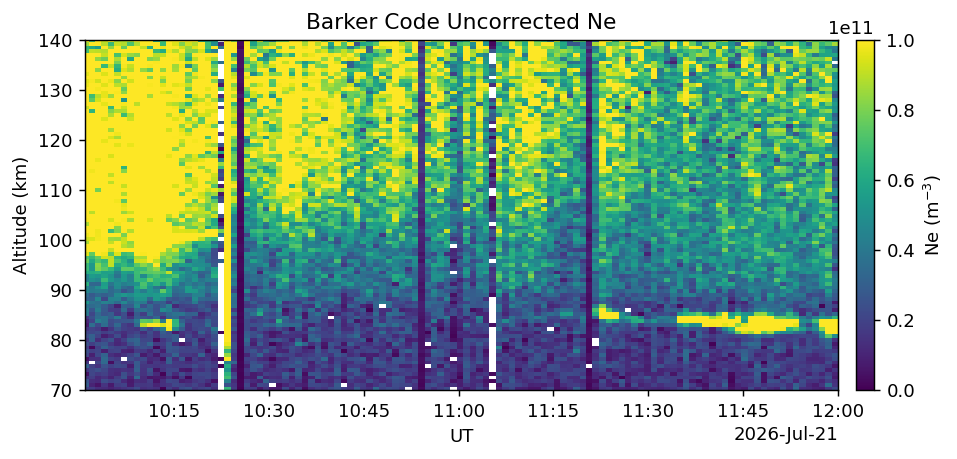

In [206]:
fig,ax=plt.subplots(dpi=130, figsize=(9,3.5))
clrs = ax.pcolormesh(mdates.date2num(bdat['time']),bdat['altitude'],bdat['ne'],vmin=0,vmax=1e11,shading='nearest')
ax.set_xlim([mdates.date2num(datetime.datetime(2026,7,21,10,0,55)),
             mdates.date2num(datetime.datetime(2026,7,21,12,0,1))])
ax.set_ylim([70,140])
locator = mdates.AutoDateLocator(minticks=8, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.set_xlabel('UT')
ax.set_ylabel('Altitude (km)')
ax.set_title('Barker Code Uncorrected Ne')

cb=fig.colorbar(clrs, pad=0.02)
cb.set_label('Ne (m$^{-3}$)')

# PMSE found in uncorrected Barker Code, these should not be represented as n_e but rather as reflectivity (not 100% sure about the units). So we need to change it and then represent it.

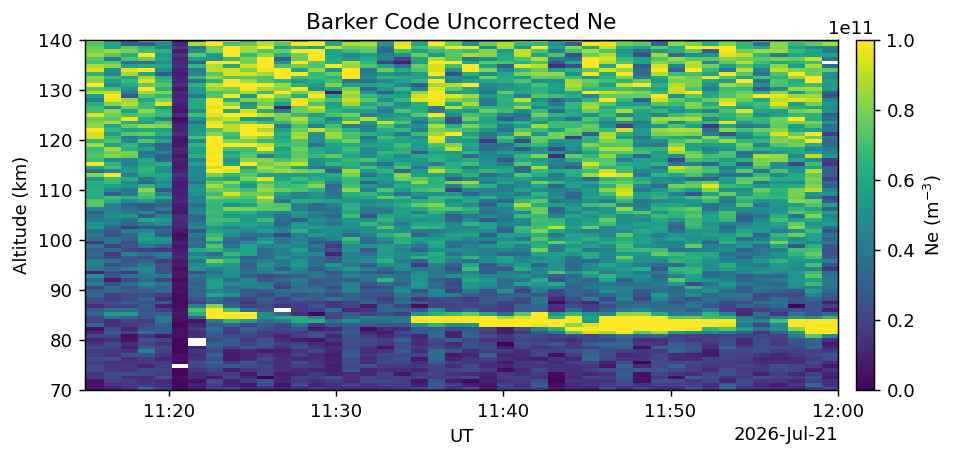

In [207]:
fig,ax=plt.subplots(dpi=130, figsize=(9,3.5))
clrs = ax.pcolormesh(mdates.date2num(bdat['time']),bdat['altitude'],bdat['ne'],vmin=0,vmax=1e11,shading='nearest')
ax.set_xlim([mdates.date2num(datetime.datetime(2026,7,21,11,15,0)),
             mdates.date2num(datetime.datetime(2026,7,21,12,0,1))])
ax.set_ylim([70,140])
locator = mdates.AutoDateLocator(minticks=8, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.set_xlabel('UT')
ax.set_ylabel('Altitude (km)')
ax.set_title('Barker Code Uncorrected Ne')

cb=fig.colorbar(clrs, pad=0.02)
cb.set_label('Ne (m$^{-3}$)')

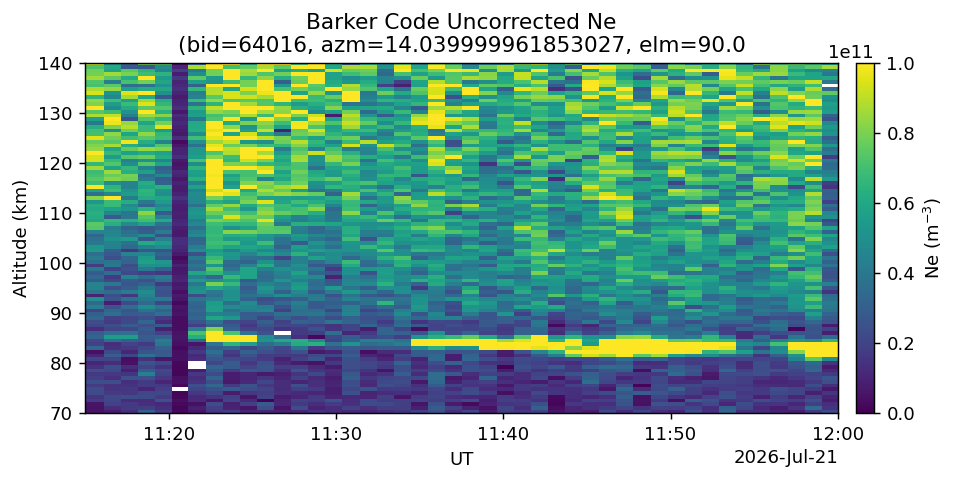

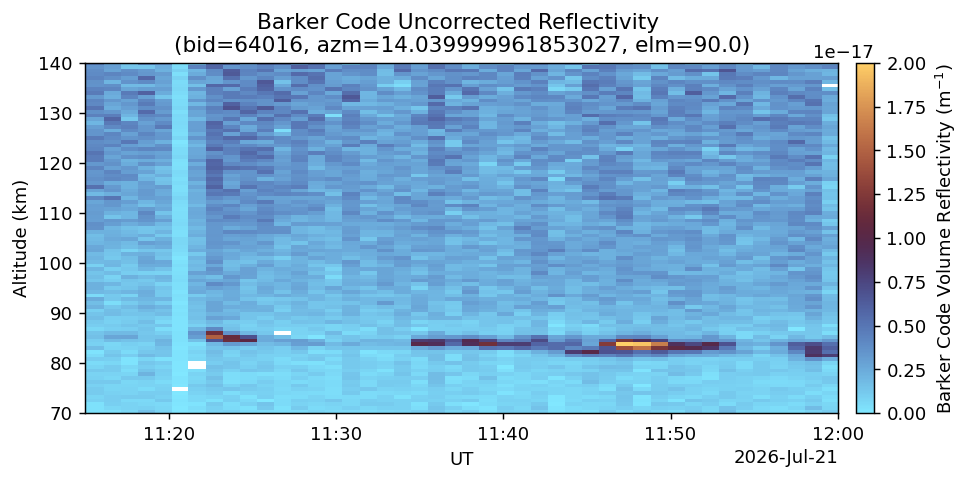

In [208]:
import cmcrameri.cm as cm

fig,ax=plt.subplots(dpi=130, figsize=(9,3.5))
clrs = ax.pcolormesh(mdates.date2num(bdat['time']),bdat['altitude'],bdat['ne'],vmin=0,vmax=1e11,shading='nearest')
ax.set_xlim([mdates.date2num(datetime.datetime(2026,7,21,11,15,0)),
             mdates.date2num(datetime.datetime(2026,7,21,12,0,1))])
ax.set_ylim([70,140])
locator = mdates.AutoDateLocator(minticks=8, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.set_xlabel('UT')
ax.set_ylabel('Altitude (km)')
ax.set_title(f'Barker Code Uncorrected Ne\n(bid={bdat['bid']}, azm={bdat['azm']}, elm={bdat['elm']}')

cb=fig.colorbar(clrs, pad=0.02)
cb.set_label('Ne (m$^{-3}$)')

sigma_factor = 4.99e-29
reflectivity = bdat['ne']*sigma_factor

fig,ax=plt.subplots(dpi=130, figsize=(9,3.5))

clrs = ax.pcolormesh(mdates.date2num(bdat['time']),bdat['altitude'],reflectivity,
                    vmin=0, vmax=0.2e-16, cmap=cm.managua_r, shading='nearest')
ax.set_xlim([mdates.date2num(datetime.datetime(2026,7,21,11,15,0)),
             mdates.date2num(datetime.datetime(2026,7,21,12,0,1))])
ax.set_ylim([70,140])
locator = mdates.AutoDateLocator(minticks=8, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.set_xlabel('UT')
ax.set_ylabel('Altitude (km)')
ax.set_title(f'Barker Code Uncorrected Reflectivity \n(bid={bdat['bid']}, azm={bdat['azm']}, elm={bdat['elm']})')

cb=fig.colorbar(clrs, pad=0.02)
cb.set_label('Barker Code Volume Reflectivity (m$^{-1}$)')

# Look at reflectivity and put on a contour plot. It is m^3 and not m^-3 on the Varney PMSE paper.

In [209]:
# for i,d in enumerate(LP_data):
#     print(f"{d['bid']}  {d['azm']:.2f}\t{d['elm']:.2f}")

# bver_ind  = np.argmin(np.abs(np.array([x['elm'] for x in LP_data]) - ( 90.0)))
# bdat    = LP_data[bver_ind]

# fig,ax=plt.subplots(dpi=130, figsize=(9,3.5))
# clrs = ax.pcolormesh(mdates.date2num(bdat['time']),bdat['altitude'],bdat['ne'],vmin=0,vmax=1e12,shading='nearest')
# ax.set_xlim([mdates.date2num(datetime.datetime(2026,7,21,10,0,0)),
#              mdates.date2num(datetime.datetime(2026,7,21,11,5,0))])
# locator = mdates.AutoDateLocator(minticks=8, maxticks=9)
# formatter = mdates.ConciseDateFormatter(locator)
# ax.xaxis.set_major_locator(locator)
# ax.xaxis.set_major_formatter(formatter)
# ax.set_xlabel('UT')
# ax.set_ylabel('Altitude (km)')
# ax.set_title('LP Fitted Ne')

# cb=fig.colorbar(clrs, pad=0.02)
# cb.set_label('Ne (m$^{-3}$)')

In [210]:

#AZM = AZIMUTH
#ELM = ELEVATION ANGLE
#BID=BEAM
print(bdat['bid'], bdat['azm'], bdat['elm'])

64016 14.039999961853027 90.0


[datetime.datetime(2026, 7, 21, 10, 0, 55, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 1, 56, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 2, 57, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 3, 58, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 4, 59, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 6, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 7, 1, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 8, 2, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 9, 6, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 10, 6, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 11, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 12, 8, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 13, 10, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 7, 21, 10, 14, 10, tzinfo=dateti

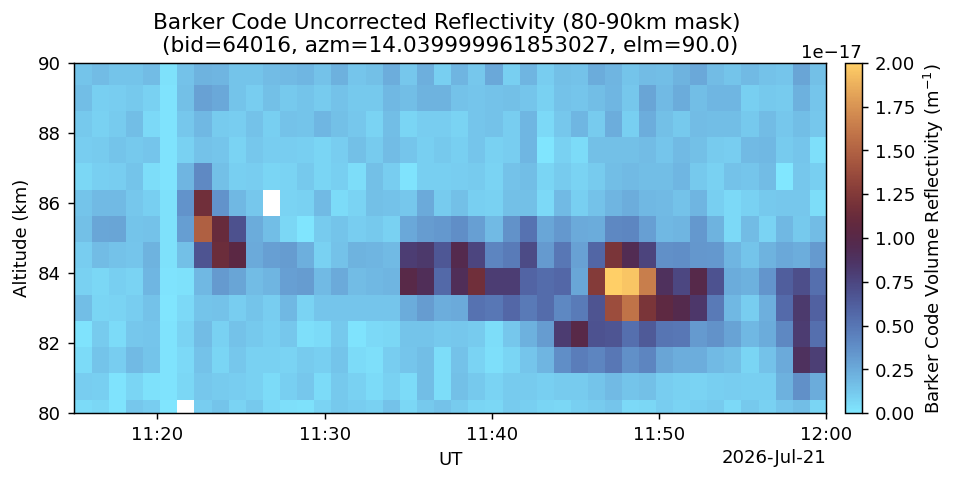

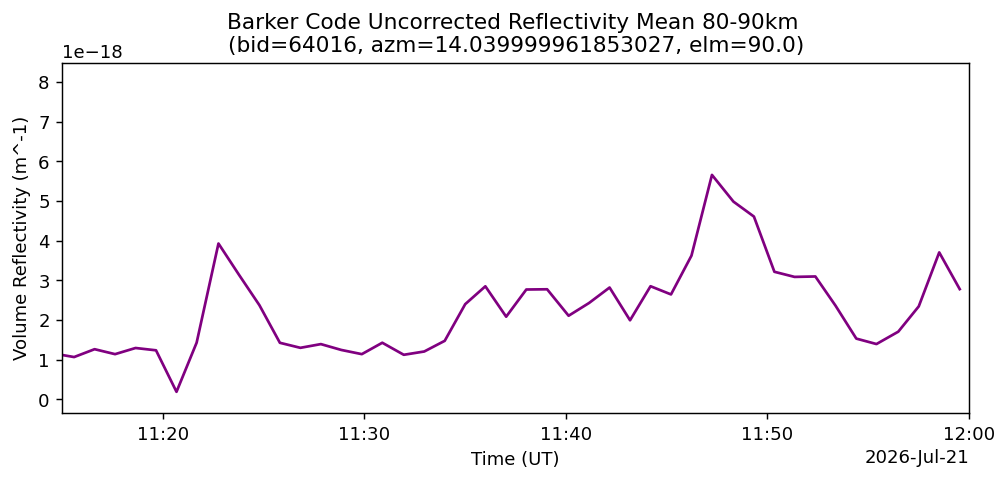

In [214]:
fig, ax = plt.subplots(dpi=130, figsize=(9,3.5))

altitude_mask = (bdat['altitude'] >= 80) & (bdat['altitude'] <= 90)

altitude_masked = bdat['altitude'][altitude_mask]
reflectivity_masked = reflectivity[altitude_mask, :]

clrs = ax.pcolormesh(mdates.date2num(bdat['time']),altitude_masked,reflectivity_masked,
                    vmin=0, vmax=0.2e-16, cmap=cm.managua_r, shading='nearest')
ax.set_xlim([mdates.date2num(datetime.datetime(2026,7,21,11,15,0)),
             mdates.date2num(datetime.datetime(2026,7,21,12,0,1))])
ax.set_ylim([80,90])
locator = mdates.AutoDateLocator(minticks=8, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.set_xlabel('UT')
ax.set_ylabel('Altitude (km)')
ax.set_title(f'Barker Code Uncorrected Reflectivity (80-90km mask) \n(bid={bdat['bid']}, azm={bdat['azm']}, elm={bdat['elm']})')

cb=fig.colorbar(clrs, pad=0.02)
cb.set_label('Barker Code Volume Reflectivity (m$^{-1}$)')

reflectivity_mean = np.nanmean(reflectivity_masked, axis=0)

fig,ax=plt.subplots(dpi=130, figsize=(9,3.5))

ax.plot(bdat['time'], reflectivity_mean, color='purple')

ax.set_xlim([mdates.date2num(datetime.datetime(2026,7,21,11,15,0)),
             mdates.date2num(datetime.datetime(2026,7,21,12,0,1))])
# ax.set_ylim([70,140])
locator = mdates.AutoDateLocator(minticks=8, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Volume Reflectivity (m^-1)')
ax.set_title(f'Barker Code Uncorrected Reflectivity Mean 80-90km \n(bid={bdat['bid']}, azm={bdat['azm']}, elm={bdat['elm']})')

print(list(bdat['time']))